# Hedonic Pricing of UFFI Homes — Python implementation

This notebook is the **Python** side of a two-language project (the R version is
in `../R/`). It estimates how much each physical characteristic of a home — and
in particular the presence of **urea-formaldehyde foam insulation (UFFI)** —
contributes to its sale price, using a small, reusable hedonic-pricing pipeline.

A plain-language walkthrough of every modelling choice is in
[`../docs/methodology.md`](../docs/methodology.md). The reusable engine lives in
[`uffi_pipeline.py`](uffi_pipeline.py); this notebook narrates it.

In [1]:
import sys; sys.path.insert(0, ".")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from uffi_pipeline import (UFFI_CONFIG, load_data, flag_influence,
                           compare_models, fit_interpretable,
                           coefficient_effects, predict_with_interval)

cfg  = UFFI_CONFIG
df   = load_data("../data/uffidata.xlsx", cfg)
print(f"{len(df)} homes, {len(cfg.features)} characteristics")
df.head()

99 homes, 10 characteristics


,year_sold,sale_price,uffi_in,brick_ext,age_45plus,basement_sf,lot_area,park_spaces,living_area,central_air,pool
0,2009,76900,1,0,1,0.000,2772.0,0,1018.330,0,0
1,2009,78000,1,0,1,153.518,4490.0,0,536.203,1,0
2,2011,79000,0,0,1,400.000,5840.0,0,721.400,1,0
3,2011,80000,0,0,1,0.000,5040.0,0,512.504,0,0
4,2010,82000,1,0,1,157.080,5440.8,0,671.680,0,0


## 1. Why model log(price)?

House prices are right-skewed — a few homes cost far more than the typical one.
Logging the target makes it nearly symmetric and turns every coefficient into an
approximate **percentage** effect on price.

skew  raw: 2.55   log: 1.12


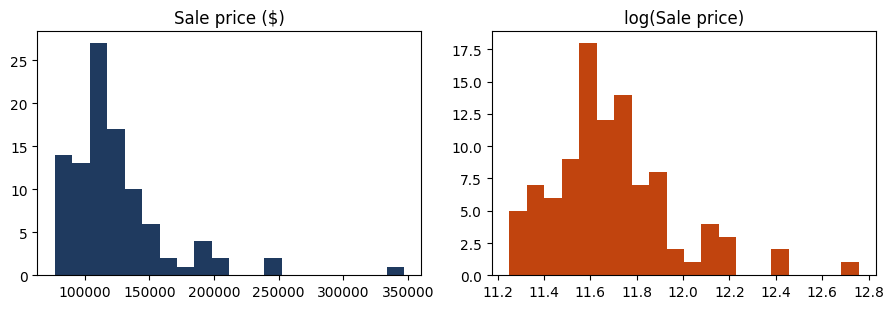

In [2]:
print(f"skew  raw: {df.sale_price.skew():.2f}   log: {np.log(df.sale_price).skew():.2f}")
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].hist(df.sale_price, bins=20, color="#1f3a5f"); ax[0].set_title("Sale price ($)")
ax[1].hist(np.log(df.sale_price), bins=20, color="#c1440e"); ax[1].set_title("log(Sale price)")
plt.tight_layout(); plt.show()

## 2. Outliers: flag, don't delete

A common "cleanup" step is to delete every home more than 1.5 SD from the mean —
which on this data loses 26% of the rows, including every sale above \$179k, and
artificially shrinks the error. We instead keep every home and merely **flag**
the influential ones with Cook's distance.

In [3]:
infl = flag_influence(df, cfg)
print(f"Influential homes flagged (kept, not deleted): {int(infl.sum())}")

Influential homes flagged (kept, not deleted): 5


## 3. Honest model comparison (10-fold cross-validation)

Every model is graded on homes it did **not** train on, and the error is
reported back in dollars. On a dataset this small, regularised linear regression
beats the tree ensembles.

,model,cv_rmse,cv_r2
0,Ridge,"$24,862",0.616
1,ElasticNet,"$25,798",0.587
2,Lasso,"$25,801",0.587
3,OLS,"$25,805",0.587
4,GradientBoosting,"$27,137",0.543
5,RandomForest,"$28,224",0.506


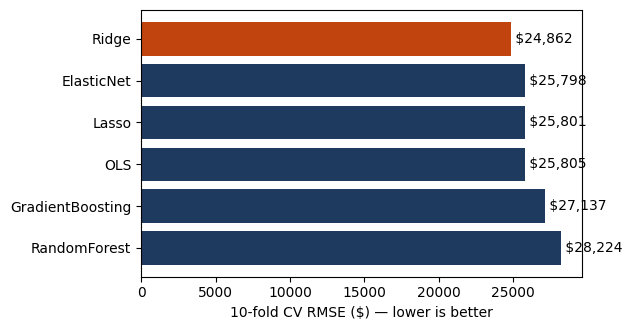

In [4]:
board = compare_models(df, cfg)
display(board.style.format({"cv_rmse": "${:,.0f}", "cv_r2": "{:.3f}"}))

fig, ax = plt.subplots(figsize=(6.4, 3.4))
colors = ["#c1440e" if m == board.iloc[0].model else "#1f3a5f" for m in board.model]
ax.barh(board.model, board.cv_rmse, color=colors); ax.invert_yaxis()
for y, v in enumerate(board.cv_rmse): ax.text(v, y, f" ${v:,.0f}", va="center")
ax.set_xlabel("10-fold CV RMSE ($) — lower is better"); plt.tight_layout(); plt.show()

## 4. What each characteristic is worth

`exp(coef) - 1` gives the approximate % price effect. Reported per
one-standard-deviation increase so a \$/SF variable and a 0/1 flag are
comparable.

In [5]:
fit = fit_interpretable(df, cfg)
eff = coefficient_effects(fit, cfg).query("term != 'const'").copy()
eff["sd"] = [df[t].std() for t in eff.term]
eff["pct_per_sd"] = (np.exp(eff.coef * eff.sd) - 1) * 100
display(eff.sort_values("pct_per_sd", key=abs, ascending=False)
          [["term", "coef", "p_value", "pct_per_sd"]]
          .style.format({"coef": "{:.4f}", "p_value": "{:.3f}", "pct_per_sd": "{:+.1f}%"}))

,term,coef,p_value,pct_per_sd
7,living_area,0.0004,0.000,+12.8%
10,year_sold,0.0397,0.000,+9.4%
9,pool,0.2755,0.001,+4.9%
6,park_spaces,0.0614,0.005,+4.4%
5,lot_area,0.0000,0.087,+2.9%
2,brick_ext,0.0511,0.086,+2.5%
1,uffi_in,-0.0605,0.076,-2.5%
4,basement_sf,0.0001,0.187,+2.2%
8,central_air,0.0313,0.285,+1.6%
3,age_45plus,-0.0051,0.908,-0.2%


The dominant drivers are **living area** and the **sale year / market cycle**.
**UFFI** carries a modest discount of roughly **−6%** (borderline significant);
in a simpler dollar-scale model it is about **−\$14,700** (p ≈ 0.02).

## 5. Pricing a specific home, with a correct interval

A proper prediction interval accounts for both residual noise and the
uncertainty in the fitted coefficients — unlike the `point ± 1.96 × SE`
shortcut, which is too narrow.

In [6]:
scenario = dict(uffi_in=1, brick_ext=0, age_45plus=1, basement_sf=0,
                lot_area=7800, park_spaces=1, living_area=1720,
                central_air=0, pool=0)
pi = predict_with_interval(df, cfg, scenario)
print(f"Predicted price: ${pi['point']:,.0f}")
print(f"95% prediction interval: ${pi['lower']:,.0f} – ${pi['upper']:,.0f}")

Predicted price: $160,913
95% prediction interval: $117,626 – $204,200


## Summary

| Choice | Why |
|---|---|
| Model `log(price)` | Removes right skew; coefficients read as % effects |
| Keep all homes, flag with Cook's D | Deleting expensive homes fakes a low error |
| 10-fold cross-validation | Grades the model out-of-sample, in dollars |
| Per-SD effects | Compares \$/SF variables and 0/1 flags fairly |
| Proper prediction interval | An honest uncertainty range |

The same pipeline runs on any priced-asset dataset by writing one
`HedonicConfig` — see [`../docs/applications.md`](../docs/applications.md).